<a href="https://colab.research.google.com/github/josejuanarana-afk/Estadistica-bayesiana/blob/main/enmutaciones.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [51]:
import numpy.random as npr
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import beta
from scipy.stats import invgamma
import pymc as pm
import arviz as az

EJEMPLO BERNOULLI

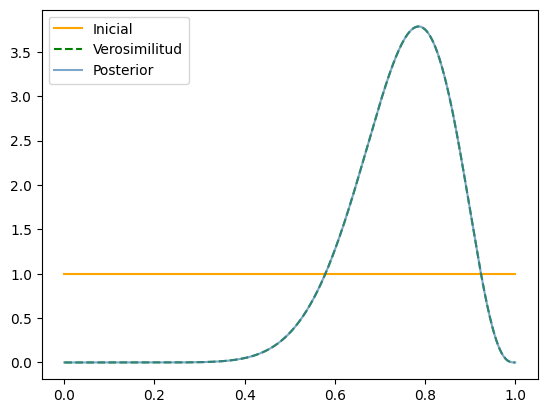

In [52]:
#1 Enmutación del codigo 1

x = np.linspace(0, 1, 500)

plt.plot(x, beta.pdf(x, 1, 1), 'orange', label='Inicial')
plt.plot(x, beta.pdf(x, 12, 4), 'g--', label='Verosimilitud')
plt.plot(x, beta.pdf(x, 12, 4), 'steelblue', label='Posterior', alpha=0.7)

plt.legend()
plt.show()

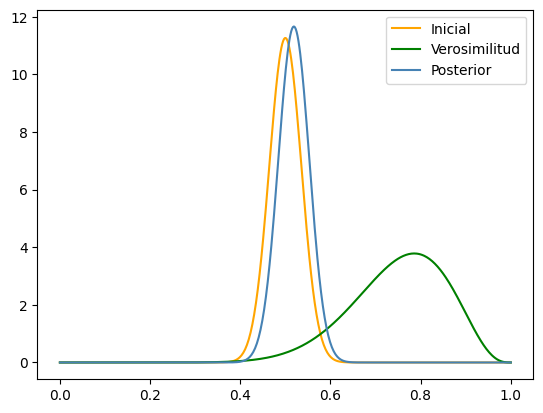

In [53]:
# 2

x = np.linspace(0, 1, 500)

# Inicial: shape1=100, shape2=100
plt.plot(x, beta.pdf(x, 100, 100), 'orange', label='Inicial')

# Verosimilitud: shape1=12, shape2=4
plt.plot(x, beta.pdf(x, 12, 4), 'green', label='Verosimilitud')

# Posterior: shape1=111, shape2=103
plt.plot(x, beta.pdf(x, 111, 103), 'steelblue', label='Posterior')

plt.legend()
plt.show()

METROPOLIS

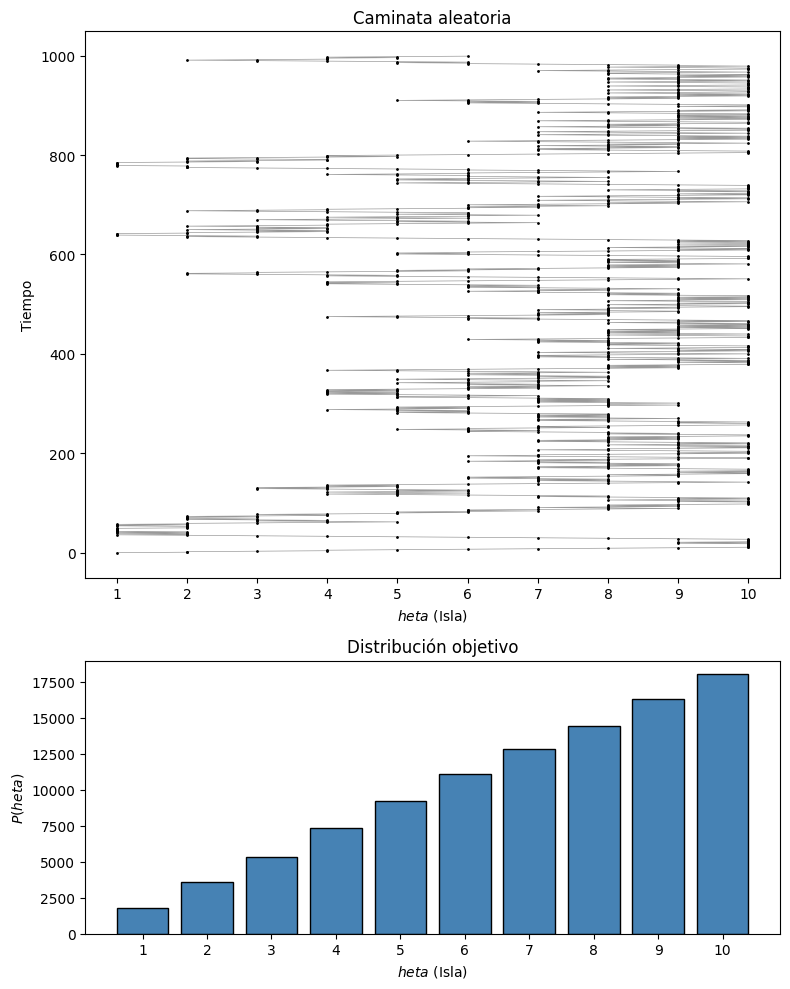

In [54]:
# 1
pob = np.arange(1, 11)  # Poblaciones del 1 al 10

def camina_isla(i):
    u = np.random.rand()
    v = (i - 1) if u < 0.5 else (i + 1) # Isla vecina

    if v < 1 or v > 10: # Límite de las islas
        return i

    p_move = min(pob[v-1] / pob[i-1], 1) # Probabilidad de aceptación
    return v if np.random.rand() < p_move else i

# Simulación
pasos = 100000
camino = np.zeros(pasos, dtype=int)
camino[0] = np.random.randint(1, 11)

for j in range(1, pasos):
    camino[j] = camina_isla(camino[j-1])

# Gráficos
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 10), gridspec_kw={'height_ratios': [2, 1]})

# 1. Caminata (Primeros 1000 pasos)
ax1.plot(camino[:1000], np.arange(1000), 'k-', alpha=0.4, lw=0.5)
ax1.scatter(camino[:1000], np.arange(1000), s=1, color='black')
ax1.set_title("Caminata aleatoria")
ax1.set_ylabel("Tiempo")
ax1.set_xlabel("$\theta$ (Isla)")
ax1.set_xticks(range(1, 11))

# 2. Histograma
ax2.hist(camino, bins=np.arange(1, 12) - 0.5, rwidth=0.8, color='steelblue', edgecolor='black')
ax2.set_title("Distribución objetivo")
ax2.set_xlabel("$\theta$ (Isla)")
ax2.set_ylabel("$P(\theta)$")
ax2.set_xticks(range(1, 11))

plt.tight_layout()
plt.show()

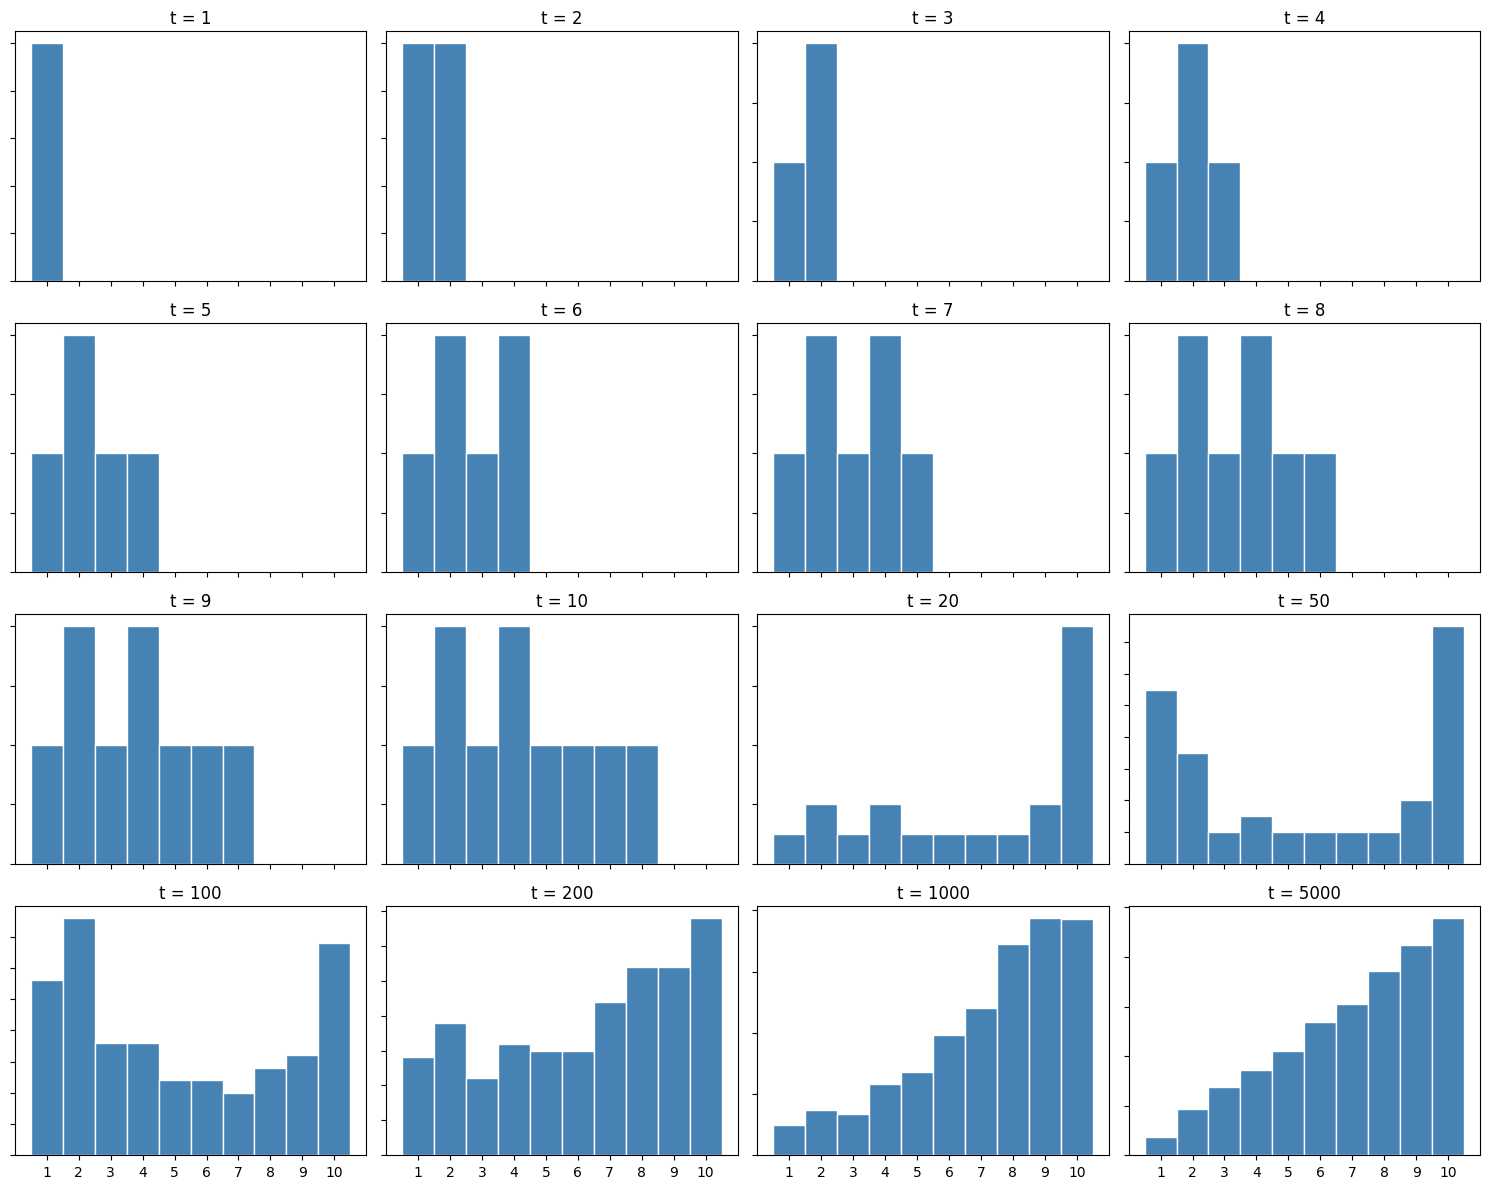

In [55]:
#2
t_values = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 20, 50, 100, 200, 1000, 5000]

fig, axes = plt.subplots(4, 4, figsize=(15, 12))
axes = axes.flatten()

for i, t in enumerate(t_values):
    # Histograma de los primeros 't' pasos
    axes[i].hist(camino[:t], bins=np.arange(1, 12) - 0.5,
                 color='steelblue', edgecolor='white')

    axes[i].set_title(f"t = {t}")
    axes[i].set_xlim(0, 11)
    axes[i].set_xticks(range(1, 11))

    # Limpiar etiquetas para que se vea como en grid.arrange
    if i < 12: axes[i].set_xticklabels([])
    axes[i].set_yticklabels([])

plt.tight_layout()
plt.show()

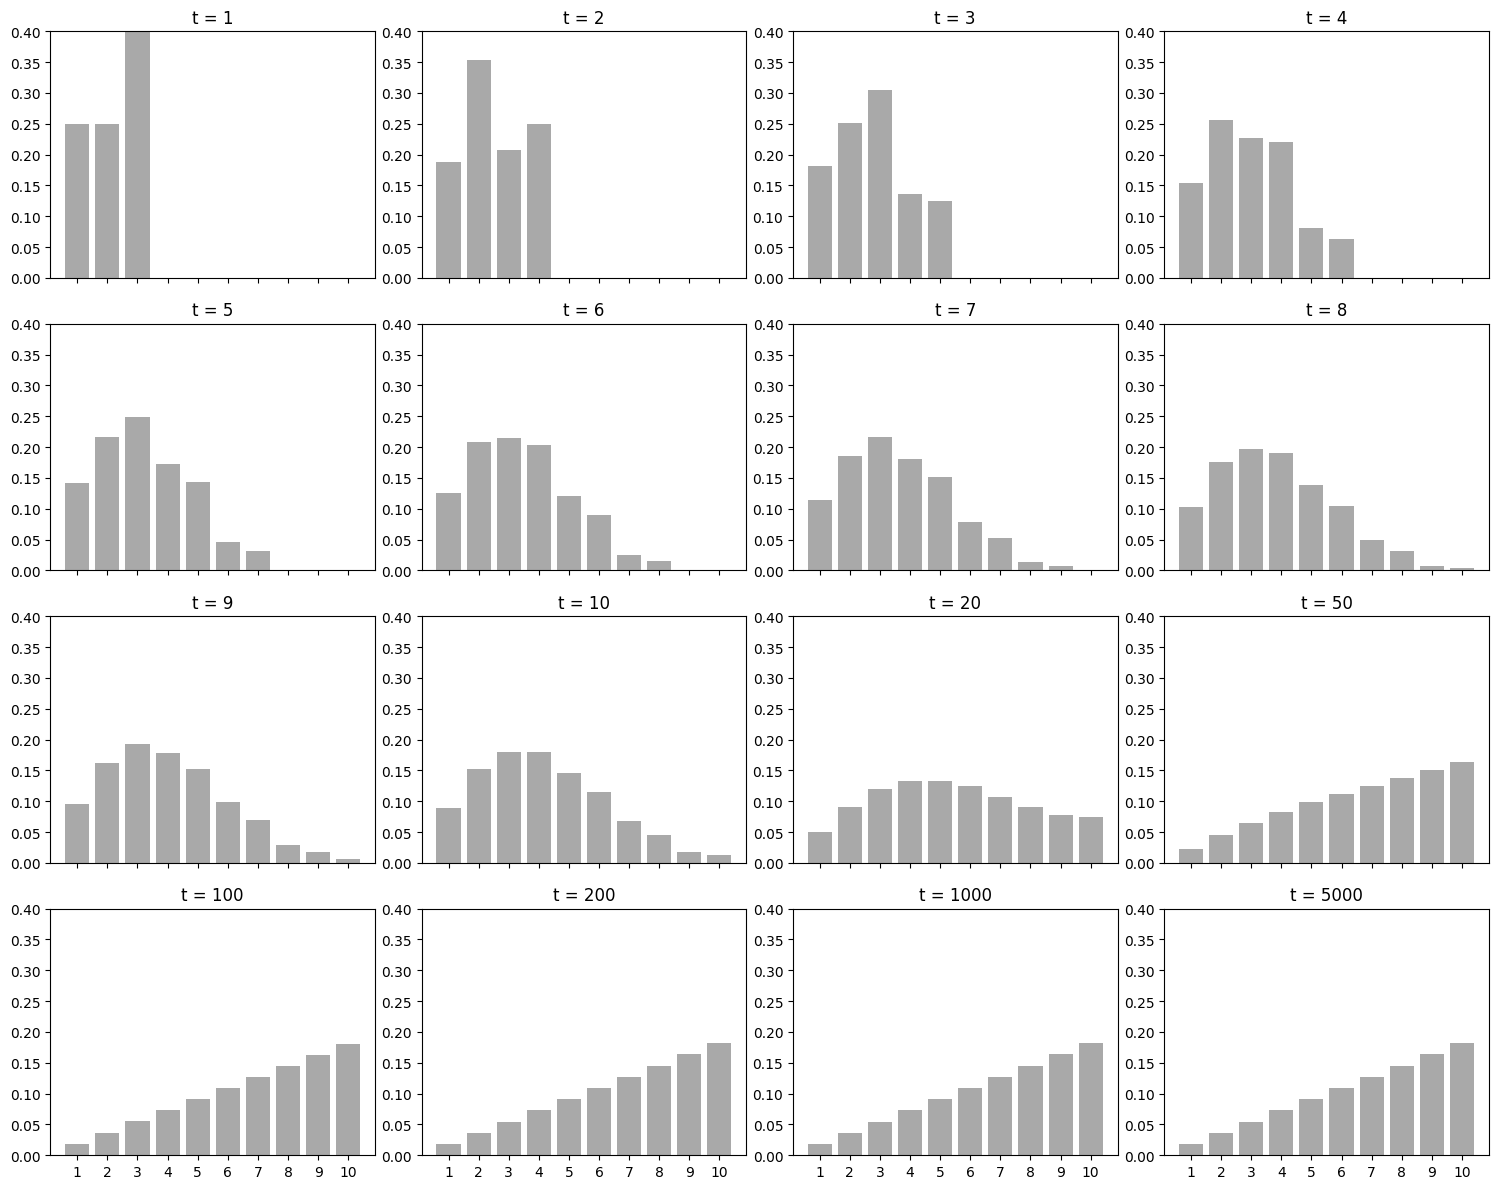

In [56]:
#3
# Población y matriz de transición
P = np.arange(1, 11)
n = len(P)
T = np.zeros((n, n))

for j in range(1, n - 1):
    T[j, j - 1] = 0.5 * min(P[j - 1] / P[j], 1)
    T[j, j + 1] = 0.5 * min(P[j + 1] / P[j], 1)
    T[j, j] = 1 - T[j, j - 1] - T[j, j + 1]

# Casos borde (isla 1 e isla 10)
T[0, 1] = 0.5 * min(P[1] / P[0], 1)
T[0, 0] = 1 - T[0, 1]
T[n-1, n-2] = 0.5 * min(P[n-2] / P[n-1], 1)
T[n-1, n-1] = 1 - T[n-1, n-2]

# Distribución inicial (probabilidad 1 de estar en isla 2)
w = np.zeros(n)
w[1] = 1

t_values = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 20, 50, 100, 200, 1000, 5000]

# Graficar
fig, axes = plt.subplots(4, 4, figsize=(15, 12))
axes = axes.flatten()

for i, t in enumerate(t_values):
    # Equivalente a w %*% (T %^% i)
    w_t = w @ np.linalg.matrix_power(T, t)

    axes[i].bar(range(1, 11), w_t, color='darkgray')
    axes[i].set_title(f"t = {t}")
    axes[i].set_ylim(0, 0.4)
    axes[i].set_xticks(range(1, 11))
    if i < 12: axes[i].set_xticklabels([])

plt.tight_layout()
plt.show()

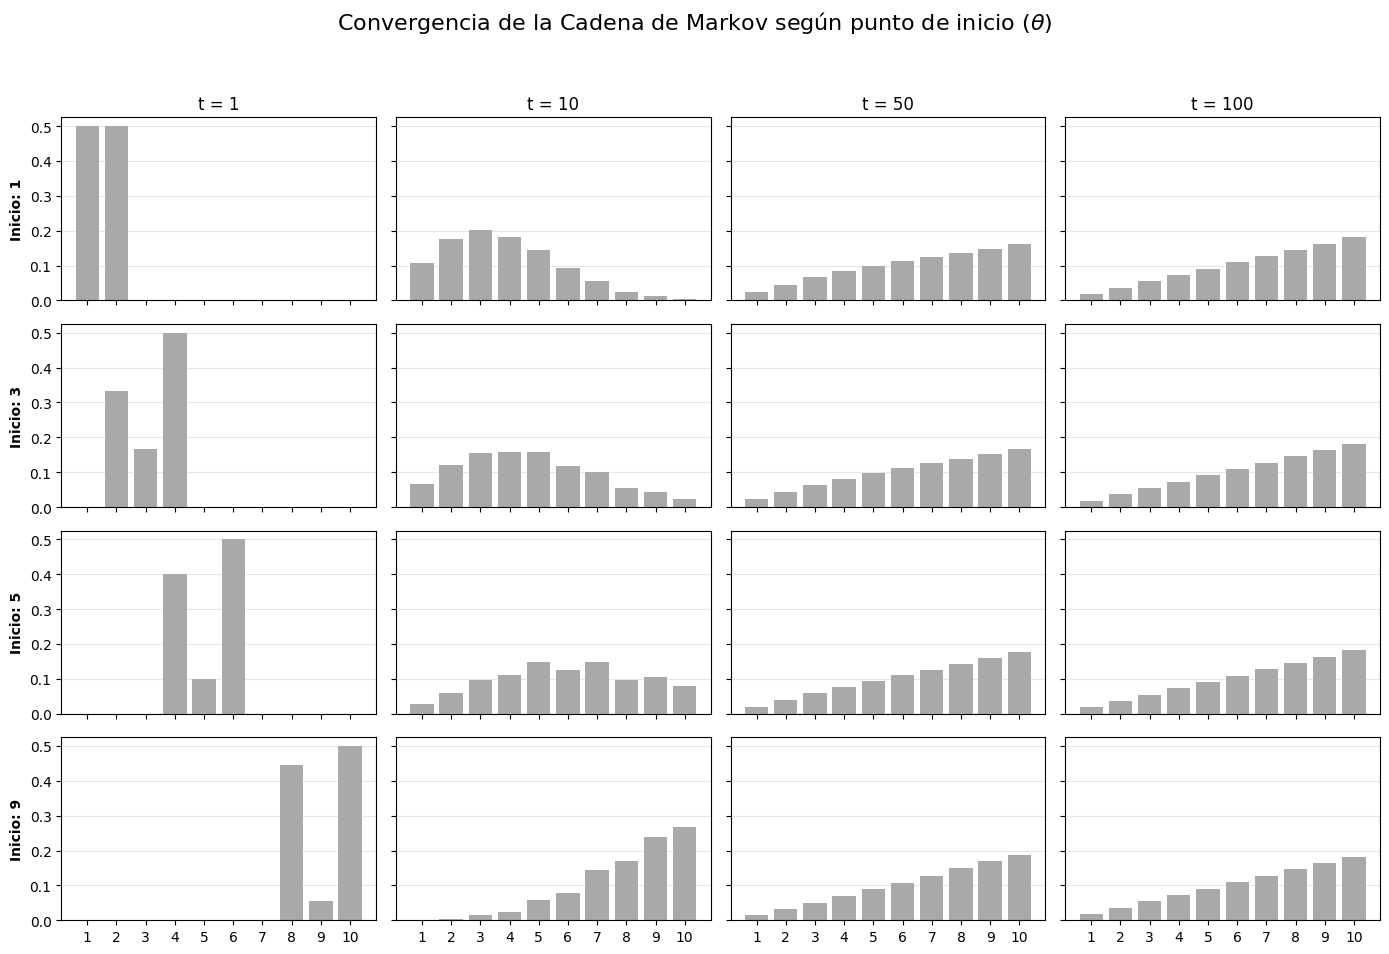

In [57]:
#4
inicios = [1, 3, 5, 9]
tiempos = [1, 10, 50, 100]

fig, axes = plt.subplots(len(inicios), len(tiempos), figsize=(14, 10), sharex=True, sharey=True)

for row, i_start in enumerate(inicios):
    # Crear vector de inicio w (isla i_start tiene prob 1)
    # Restamos 1 porque Python usa índices desde 0
    w = np.zeros(n)
    w[i_start - 1] = 1

    for col, t in enumerate(tiempos):
        # Calcular w * T^t
        w_t = w @ np.linalg.matrix_power(T, t)

        ax = axes[row, col]
        ax.bar(range(1, 11), w_t, color='darkgray')

        # Etiquetas de las columnas (Tiempo)
        if row == 0:
            ax.set_title(f"t = {t}")

        # Etiquetas de las filas (Inicio)
        if col == 0:
            ax.set_ylabel(f"Inicio: {i_start}", fontweight='bold')

        ax.set_xticks(range(1, 11))
        ax.grid(axis='y', alpha=0.3)

plt.suptitle(r"Convergencia de la Cadena de Markov según punto de inicio ($\theta$)", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Caso general

In [58]:
#1
from scipy.stats import beta

# p(theta) con theta = 0.4, a = 2, b = 2
print(beta.pdf(0.4, 2, 2))

# Distribución inicial (Prior)
def prior(a=1, b=1):
    return lambda theta: beta.pdf(theta, a, b)

# Verosimilitud binomial (Likelihood)
def like_bern(z, N):
    return lambda theta: theta**z * (1 - theta)**(N - z)

# Instanciar funciones
mi_prior = prior(a=1, b=1)
mi_like = like_bern(z=11, N=14)

# Posterior no normalizada
def post_rel_prob(theta):
    return mi_like(theta) * mi_prior(theta)

# Prueba
print(post_rel_prob(0.4))

1.4400000000000004
9.05969664e-06


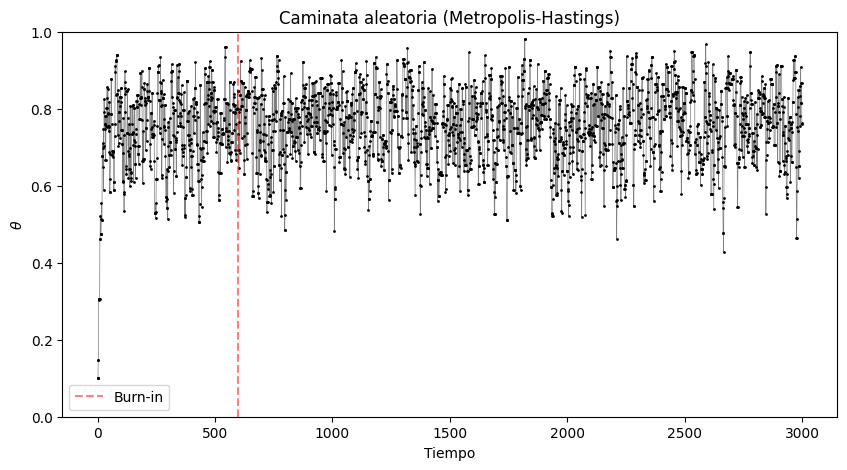

In [59]:
#2
# Parámetros y funciones base
N, z = 14, 11
mi_prior = lambda theta: beta.pdf(theta, 1, 1)
mi_like = lambda theta: theta**z * (1 - theta)**(N - z)
post_rel_prob = lambda theta: mi_like(theta) * mi_prior(theta)

def camina_aleat(theta):
    # Generar propuesta con distribución normal
    theta_prop = theta + np.random.normal(0, 0.1)

    # Validar dominio [0, 1]
    if theta_prop < 0 or theta_prop > 1:
        return theta

    # Probabilidad de aceptación
    p_move = min(post_rel_prob(theta_prop) / post_rel_prob(theta), 1)

    return theta_prop if np.random.rand() < p_move else theta

# Simulación
np.random.seed(47405)
pasos = 6000
camino = np.zeros(pasos)
camino[0] = 0.1

for j in range(1, pasos):
    camino[j] = camina_aleat(camino[j-1])

# Gráfico de la caminata (Trace plot)
plt.figure(figsize=(10, 5))
plt.plot(np.arange(3000), camino[:3000], color='black', alpha=0.5, lw=0.5)
plt.scatter(np.arange(3000), camino[:3000], s=1, color='black')

plt.axvline(x=600, color='red', linestyle='--', alpha=0.5, label="Burn-in")
plt.ylim(0, 1)
plt.title("Caminata aleatoria (Metropolis-Hastings)")
plt.xlabel("Tiempo")
plt.ylabel(r"$\theta$")
plt.legend()
plt.show()

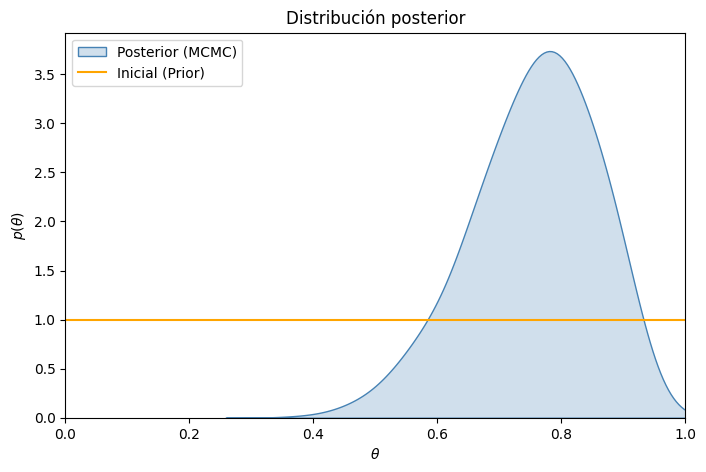

In [60]:
#3

# 1. Filtrar el calentamiento (pasos > 600)
caminata_f = camino[600:]

# 2. Graficar
plt.figure(figsize=(8, 5))

# Densidad de la posterior (ajuste de banda bw_adjust=2 para suavizar)
sns.kdeplot(caminata_f, bw_adjust=2, label='Posterior (MCMC)', fill=True, color='steelblue')

# Graficar la Inicial (Prior) para comparar
x_range = np.linspace(0, 1, 100)
plt.plot(x_range, [mi_prior(val) for val in x_range], color='orange', label='Inicial (Prior)')

plt.title("Distribución posterior")
plt.xlabel(r"$\theta$")
plt.ylabel(r"$p(\theta)$")
plt.xlim(0, 1)
plt.legend()
plt.show()


In [61]:
#4

media_post = np.mean(caminata_f)
desv_est_post = np.std(caminata_f)

print(f"Media posterior: {media_post:.3f}")
print(f"Desviación estándar: {desv_est_post:.3f}")

sims_y = np.random.binomial(1, caminata_f)

prob_predictiva = np.mean(sims_y)
print(f"Probabilidad predictiva p(y=1 | x): {prob_predictiva:.2f}")

Media posterior: 0.756
Desviación estándar: 0.101
Probabilidad predictiva p(y=1 | x): 0.75


Inferencia de dos proporciones binomiales

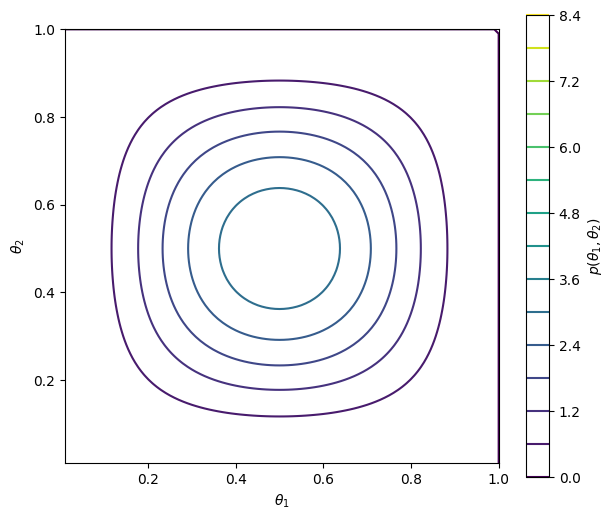

In [62]:
#1
# Crear la rejilla (grid)
x = np.linspace(0.01, 1, 100)
y = np.linspace(0.01, 1, 100)
X, Y = np.meshgrid(x, y)

# Calcular la densidad conjunta (asumiendo independencia)
Z = beta.pdf(X, 3, 3) * beta.pdf(Y, 3, 3)

# Graficar contornos
plt.figure(figsize=(7, 6))
niveles = np.arange(0, 8.6, 0.6)
cp = plt.contour(X, Y, Z, levels=niveles, cmap='viridis')

# Estética y etiquetas
plt.colorbar(cp, label=r'$p(\theta_1, \theta_2)$')
plt.xlabel(r'$\theta_1$')
plt.ylabel(r'$\theta_2$')
plt.gca().set_aspect('equal') # coord_fixed()
plt.show()

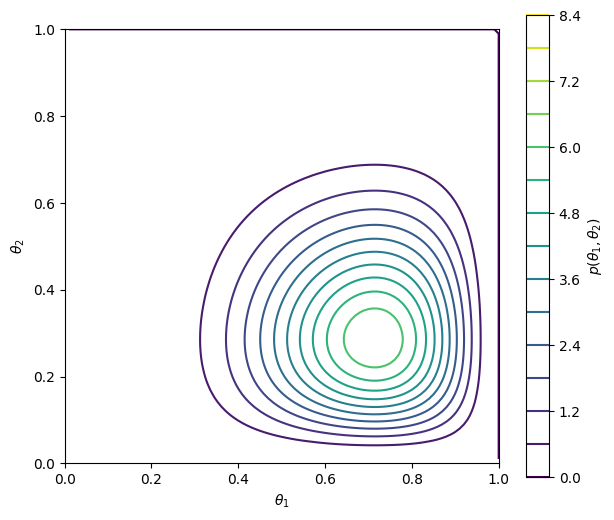

In [63]:
#2
x = np.linspace(0.01, 1, 100)
y = np.linspace(0.01, 1, 100)
X, Y = np.meshgrid(x, y)

Z = beta.pdf(X, 6, 3) * beta.pdf(Y, 3, 6)

plt.figure(figsize=(7, 6))
niveles = np.arange(0, 8.6, 0.6)
cp = plt.contour(X, Y, Z, levels=niveles, cmap='viridis')

plt.colorbar(cp, label=r'$p(\theta_1, \theta_2)$')
plt.xlabel(r'$\theta_1$')
plt.ylabel(r'$\theta_2$')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.gca().set_aspect('equal')
plt.show()

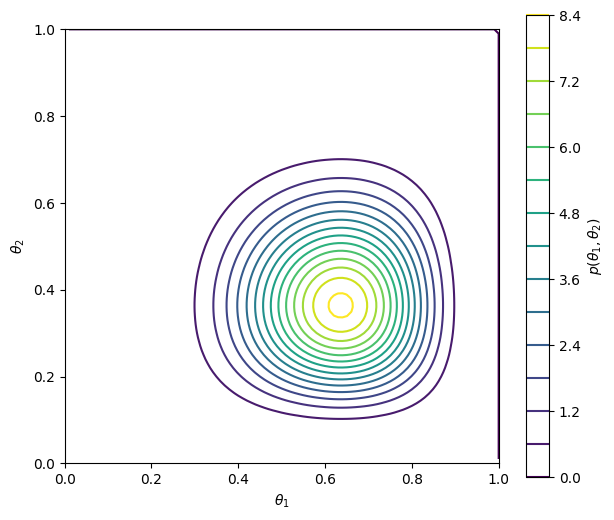

In [64]:
#3

x = np.linspace(0.01, 1, 100)
y = np.linspace(0.01, 1, 100)
X, Y = np.meshgrid(x, y)

Z = beta.pdf(X, 8, 5) * beta.pdf(Y, 5, 8)

plt.figure(figsize=(7, 6))
levels = np.arange(0, 8.6, 0.6)
cp = plt.contour(X, Y, Z, levels=levels, cmap='viridis')

plt.colorbar(cp, label=r'$p(\theta_1, \theta_2)$')
plt.xlabel(r'$\theta_1$')
plt.ylabel(r'$\theta_2$')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.gca().set_aspect('equal')
plt.show()

Metrópolis 2

In [65]:
#1
from scipy.stats import beta

def like_bern2(z1, n1, z2, n2):
    return lambda theta: (theta[0]**z1 * (1 - theta[0])**(n1 - z1) * theta[1]**z2 * (1 - theta[1])**(n2 - z2))

def prior2(a1=3, b1=3, a2=3, b2=3):
    return lambda theta: beta.pdf(theta[0], a1, b1) * beta.pdf(theta[1], a2, b2)

def post_rel_prob2(theta):
    return mi_like(theta) * mi_prior(theta)

In [66]:
#2
z1, n1 = 5, 7
z2, n2 = 2, 7

mi_prior = prior2(a1=3, b1=3, a2=3, b2=3)
mi_like = like_bern2(z1=z1, n1=n1, z2=z2, n2=n2)


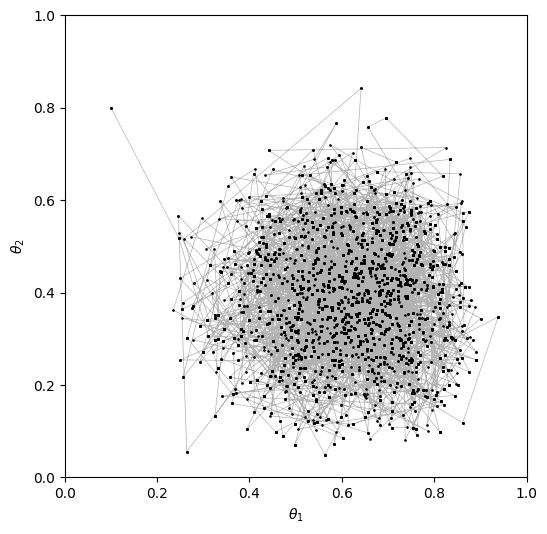

In [67]:
#3

def camina_aleat2(theta):
    salto_prop = np.random.multivariate_normal([0, 0], [[0.1, 0], [0, 0.1]])
    theta_prop = theta + salto_prop

    if np.any(theta_prop < 0) or np.any(theta_prop > 1):
        return theta

    p_move = min(post_rel_prob2(theta_prop) / post_rel_prob2(theta), 1)

    if p_move > np.random.rand():
        return theta_prop
    else:
        return theta

np.random.seed(47405)
pasos = 6000
camino = np.zeros((pasos, 2))
camino[0] = [0.1, 0.8]

for j in range(1, pasos):
    camino[j] = camina_aleat2(camino[j-1])

plt.figure(figsize=(6, 6))
plt.plot(camino[:, 0], camino[:, 1], color='black', alpha=0.3, lw=0.5)
plt.scatter(camino[:, 0], camino[:, 1], s=0.8, color='black')
plt.xlabel(r'$\theta_1$')
plt.ylabel(r'$\theta_2$')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.gca().set_aspect('equal')
plt.show()

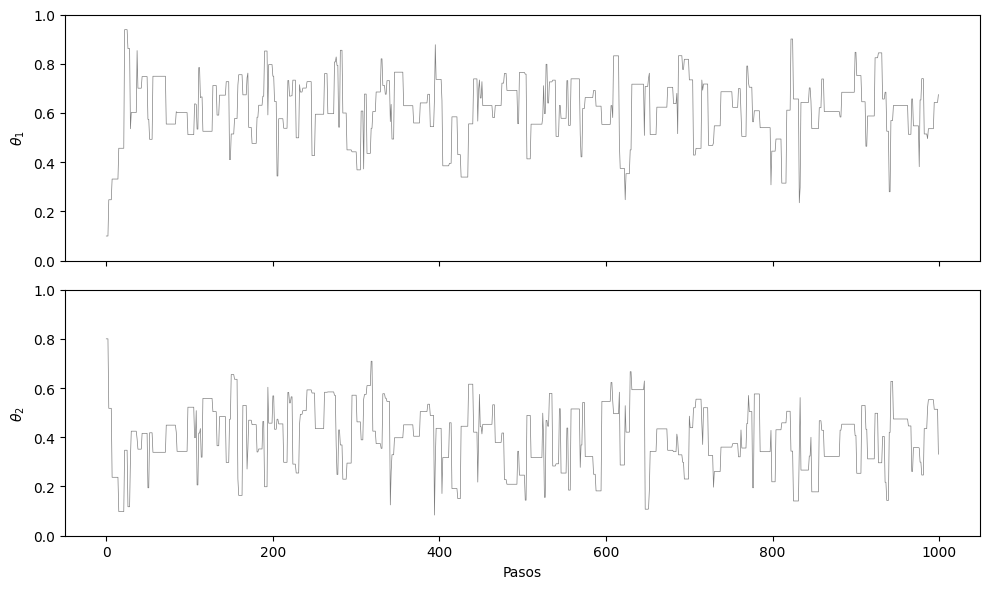

In [68]:
#4

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axes[0].plot(camino[:1000, 0], color='black', lw=0.5, alpha=0.5)
axes[0].set_ylabel(r"$\theta_1$")
axes[0].set_ylim(0, 1)

axes[1].plot(camino[:1000, 1], color='black', lw=0.5, alpha=0.5)
axes[1].set_ylabel(r"$\theta_2$")
axes[1].set_ylim(0, 1)
axes[1].set_xlabel("Pasos")

plt.tight_layout()
plt.show()

Muestreador de Gibbs

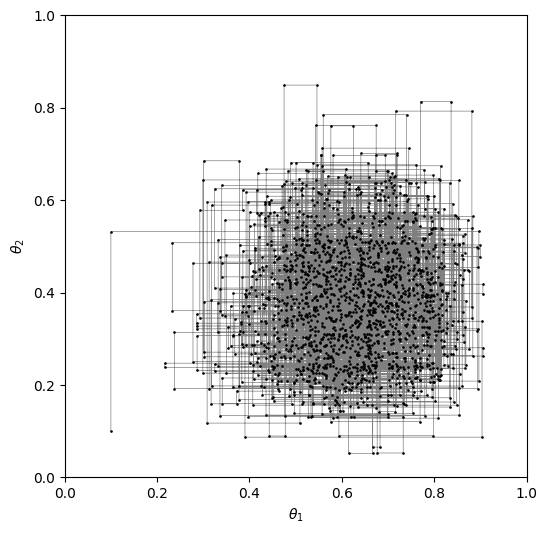

In [69]:
#1

# Parámetros (basados en los bloques anteriores)
z1, n1, a1, b1 = 5, 7, 3, 3
z2, n2, a2, b2 = 2, 7, 3, 3

pasos = 12000
camino = np.zeros((pasos, 2))
camino[0] = [0.1, 0.1]

# Muestreador de Gibbs (Gibbs Sampler)
for j in range(1, pasos):
    # En R, j=2 es par. En Python, range(1, pasos) empieza en j=1 (par para el índice)
    # R: j %% 2 == 0 (par) -> actualiza theta_2
    # R: j %% 2 != 0 (impar) -> actualiza theta_1

    if (j + 1) % 2 != 0: # Impar en la lógica de R (j=3, 5...)
        camino[j, 0] = np.random.beta(z1 + a1, n1 - z1 + b1)
        camino[j, 1] = camino[j - 1, 1]
    else: # Par en la lógica de R (j=2, 4...)
        camino[j, 1] = np.random.beta(z2 + a2, n2 - z2 + b2)
        camino[j, 0] = camino[j - 1, 0]

# Gráfico
plt.figure(figsize=(6, 6))
plt.plot(camino[:2000, 0], camino[:2000, 1], color='black', alpha=0.5, lw=0.5)
plt.scatter(camino[:2000, 0], camino[:2000, 1], s=0.8, color='black')

plt.xlabel(r"$\theta_1$")
plt.ylabel(r"$\theta_2$")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.gca().set_aspect('equal')
plt.show()

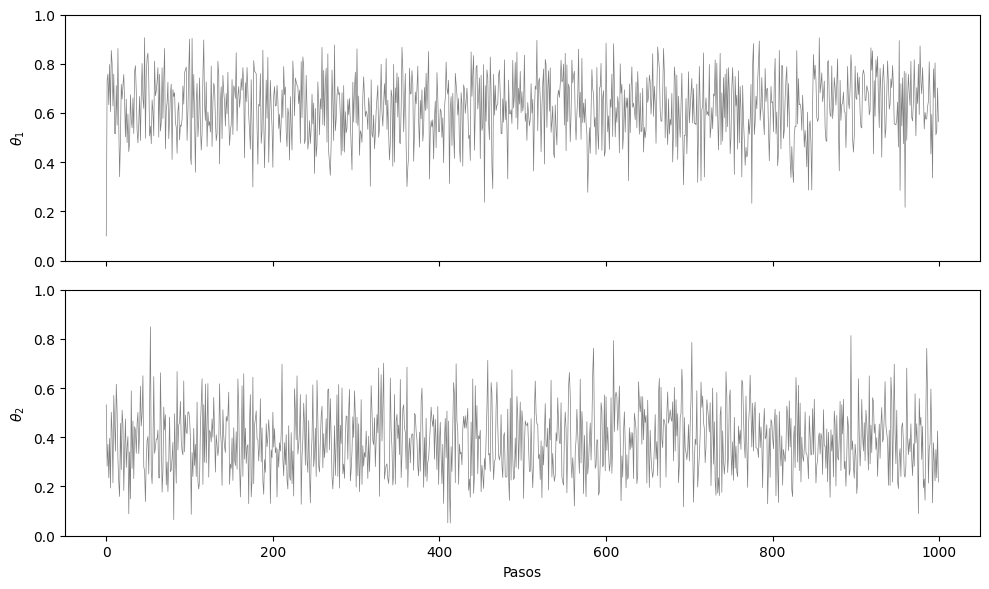

In [70]:
# 2

# Seleccionar solo los pasos donde ambos parámetros ya fueron actualizados (pasos pares)
camino_g = camino[1::2]

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

# Graficar theta_1 (primeros 1000 estados completos)
axes[0].plot(camino_g[:1000, 0], color='black', lw=0.5, alpha=0.5)
axes[0].set_ylabel(r"$\theta_1$")
axes[0].set_ylim(0, 1)

# Graficar theta_2 (primeros 1000 estados completos)
axes[1].plot(camino_g[:1000, 1], color='black', lw=0.5, alpha=0.5)
axes[1].set_ylabel(r"$\theta_2$")
axes[1].set_ylim(0, 1)
axes[1].set_xlabel("Pasos")

plt.tight_layout()
plt.show()


Ejemplo normal

In [71]:
#1

x_gamma = np.random.gamma(shape=5, scale=1, size=2000)
x_igamma = 1 / x_gamma

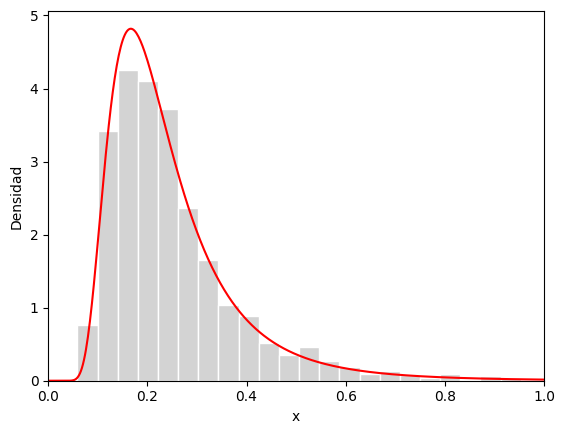

In [72]:
#2
x = np.linspace(0, 1, 500)

plt.hist(x_igamma, bins=40, density=True, color='lightgray', edgecolor='white')
plt.plot(x, invgamma.pdf(x, 5, scale=1), 'r')

plt.xlim(0, 1)
plt.xlabel("x")
plt.ylabel("Densidad")
plt.show()

In [73]:
#3
import numpy as np

np.random.seed(122)
N = 50
x = np.random.normal(2, 2, N)
x

array([ 2.96936028,  0.35567767,  1.32651641, -1.32677878,  5.43857538,
       -0.83414994, -0.76889073,  2.80577325,  3.18953828,  0.16813447,
       -1.00993137, -3.87649966,  1.45749776,  0.45240954, -0.78070906,
        2.55177684,  4.3109366 ,  2.45532162,  1.5665185 ,  4.38350281,
        3.11427729,  2.53624752, -0.03641607,  0.89702595,  3.23870331,
        1.00841663,  3.5141123 ,  0.9156496 ,  2.19141624,  2.17367789,
        1.59326529,  2.52167559,  6.04427676, -0.36282139,  3.15907615,
        2.07837736,  4.74686691,  1.37930574, -0.61071836,  2.10263961,
        1.74194258,  1.13161668,  2.09207342, -1.48638161,  1.1294175 ,
        2.21297958,  0.47377764, -1.73632316,  0.81068412, -0.58455839])

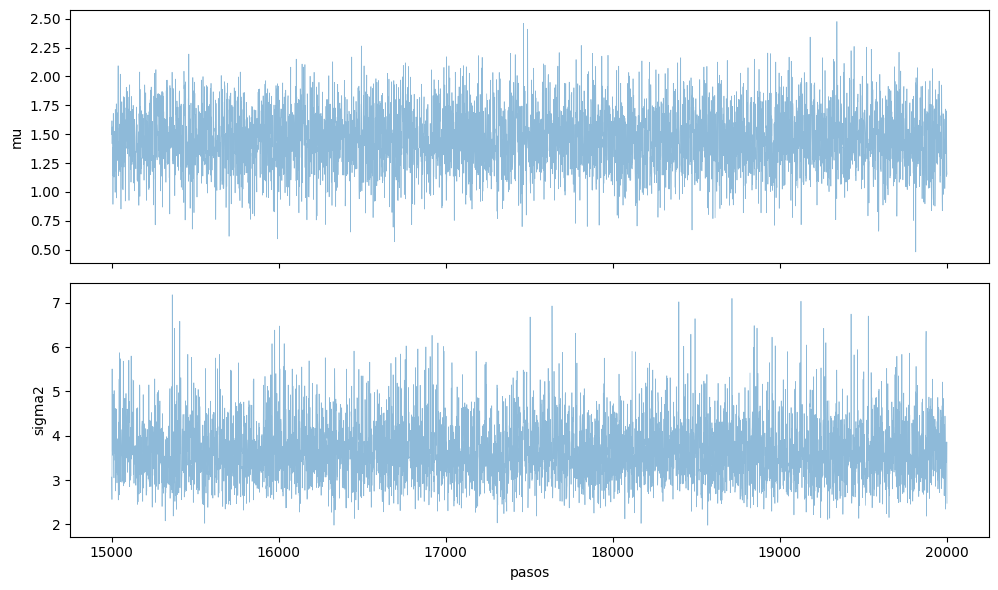

In [74]:
#4

m, tau2, alpha, beta = 1.5, 16, 3, 3
pasos = 20000
camino = np.zeros((pasos + 1, 2))
camino[0, 0] = 0

for j in range(1, pasos + 1):
    # Actualizar sigma2
    mu = camino[j - 1, 0]
    a = N / 2 + alpha
    b = np.sum((x - mu) ** 2) / 2 + beta
    camino[j - 1, 1] = 1 / np.random.gamma(a, 1/b)

    # Actualizar mu
    sigma2 = camino[j - 1, 1]
    media = (N * tau2 * np.mean(x) + sigma2 * m) / (N * tau2 + sigma2)
    var = (sigma2 * tau2) / (N * tau2 + sigma2)
    camino[j, 0] = np.random.normal(media, np.sqrt(var))

# Filtrar pasos finales (burn-in)
mu_vals = camino[15000:pasos, 0]
sigma2_vals = camino[15000:pasos, 1]
idx = np.arange(15001, pasos + 1)

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axes[0].plot(idx, mu_vals, lw=0.5, alpha=0.5)
axes[0].set_ylabel("mu")

axes[1].plot(idx, sigma2_vals, lw=0.5, alpha=0.5)
axes[1].set_ylabel("sigma2")

plt.xlabel("pasos")
plt.tight_layout()
plt.show()

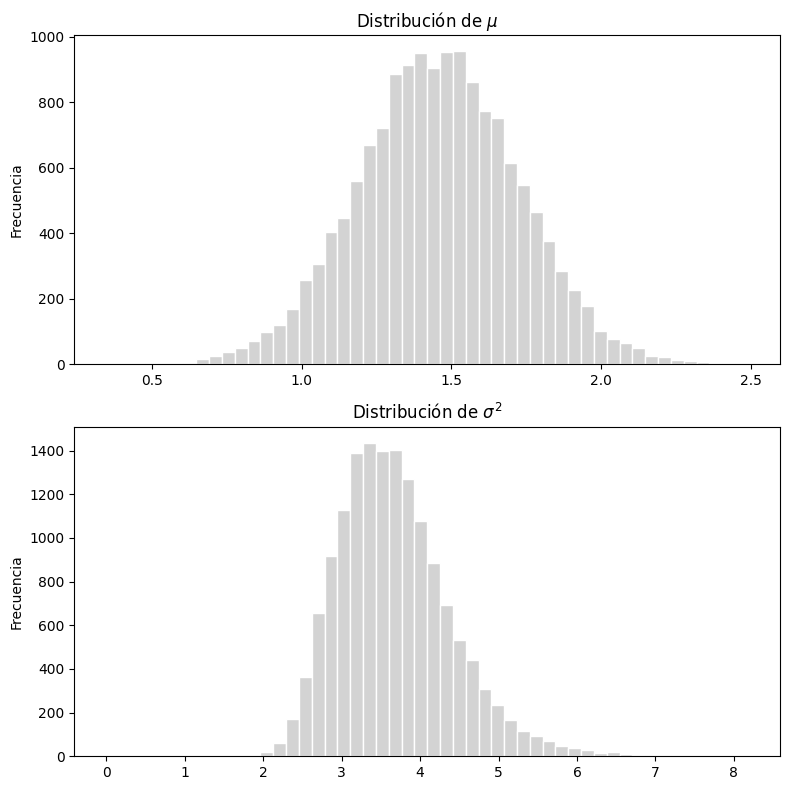

In [75]:
#4

# Filtrar pasos > 5000
mu_post = camino[5001:, 0]
sigma2_post = camino[5001:, 1]

fig, axes = plt.subplots(2, 1, figsize=(8, 8))

# Histograma para mu
axes[0].hist(mu_post, bins=50, color='lightgray', edgecolor='white')
axes[0].set_title(r"Distribución de $\mu$")
axes[0].set_ylabel("Frecuencia")

# Histograma para sigma2
axes[1].hist(sigma2_post, bins=50, color='lightgray', edgecolor='white')
axes[1].set_title(r"Distribución de $\sigma^2$")
axes[1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()


In [76]:
#5

# Filtrar el calentamiento (pasos > 1000) directamente de los arreglos
df = pd.DataFrame({
    'mu': camino[1001:, 0],
    'sigma2': camino[1001:, 1]
})

# Convertir a formato largo (long format) para emular caminata_g
df_long = df.melt(var_name='parametro', value_name='val')

# Agrupar y calcular estadísticas
resumen = df_long.groupby('parametro')['val'].agg(['mean', 'std', 'median'])

print(resumen)

               mean       std    median
parametro                              
mu         1.456417  0.269197  1.456008
sigma2     3.670688  0.719874  3.588471


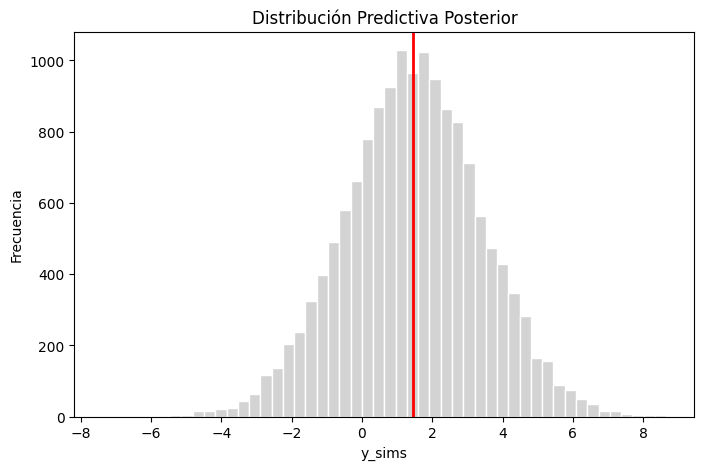

In [77]:
#6

# Filtrar pasos > 5000
mu_f = camino[5001:, 0]
sigma2_f = camino[5001:, 1]

# Generar simulaciones (usando la raíz cuadrada de sigma2 para la desviación estándar)
y_sims = np.random.normal(mu_f, np.sqrt(sigma2_f))

# Graficar histograma con la media
plt.figure(figsize=(8, 5))
plt.hist(y_sims, bins=50, color='lightgray', edgecolor='white')
plt.axvline(np.mean(y_sims), color='red', linewidth=2)

plt.title("Distribución Predictiva Posterior")
plt.xlabel("y_sims")
plt.ylabel("Frecuencia")
plt.show()

JAGS

In [78]:
#1

# Asumiendo que 'x' y 'N' ya están definidos en tu espacio de trabajo
with pm.Model() as modelo_normal:
    # Iniciales (Priors)
    # En JAGS dgamma(3,3) usa shape y rate; en PyMC es igual (alpha, beta)
    nu = pm.Gamma('nu', alpha=3, beta=3)

    # sigma2 es una variable transformada (determinística)
    sigma2 = pm.Deterministic('sigma2', 1 / nu)

    # En JAGS dnorm(1.5, 1/16) usa media y precisión.
    # En PyMC Normal puede usar 'tau' para precisión.
    mu = pm.Normal('mu', mu=1.5, tau=1/16)

    # Verosimilitud (Likelihood)
    obs = pm.Normal('x', mu=mu, tau=nu, observed=x)

    # Para ejecutar el muestreo:
    # trace = pm.sample(2000)

In [79]:
pip install pymc

In [80]:
#2

# 1. Definir valores iniciales (equivalente a jags.inits)
def get_inits():
    return {
        "mu": np.random.normal(0, 20),
        "nu": 1 / np.random.uniform(0.1, 100)
    }

# 2. Definir el modelo y ejecutar el muestreo (jags_fit)
with pm.Model() as modelo_jags:
    # Priors
    nu = pm.Gamma('nu', alpha=3, beta=3)
    mu = pm.Normal('mu', mu=1.5, tau=1/16)

    # Parámetro derivado (para guardar en el trace)
    sigma2 = pm.Deterministic('sigma2', 1 / nu)

    # Verosimilitud
    obs = pm.Normal('x', mu=mu, tau=nu, observed=x)

    # Muestreo
    # draws: pasos útiles (n.iter - n.burnin)
    # tune: calentamiento (n.burnin)
    jags_fit = pm.sample(
        draws=9000,
        tune=1000,
        chains=1,
        initvals=get_inits()
    )

Output()

In [81]:
#3

# Resumen de estadísticas posteriores
resumen = az.summary(jags_fit, var_names=["mu", "nu", "sigma2"])
print(resumen)

Shape validation failed: input_shape: (1, 9000), minimum_shape: (chains=2, draws=4)


         mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
mu      1.464  0.271   0.958    1.976      0.003    0.003    8116.0    5800.0   
nu      0.282  0.055   0.189    0.394      0.001    0.001    8844.0    6672.0   
sigma2  3.688  0.746   2.378    5.050      0.008    0.009    8844.0    6672.0   

        r_hat  
mu        NaN  
nu        NaN  
sigma2    NaN  


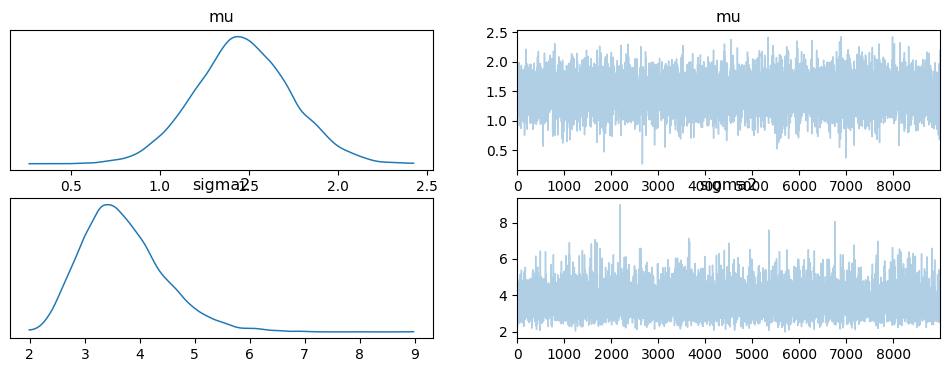

In [82]:
#4
# El equivalente exacto a traceplot
az.plot_trace(jags_fit, var_names=["mu", "sigma2"])
plt.show()

In [83]:
#5

print(jags_fit.groups())


print(list(jags_fit.posterior.data_vars))

print(jags_fit.posterior.coords)

['posterior', 'sample_stats', 'observed_data']
['mu', 'nu', 'sigma2']
Coordinates:
  * chain    (chain) int64 8B 0
  * draw     (draw) int64 72kB 0 1 2 3 4 5 6 ... 8994 8995 8996 8997 8998 8999


In [84]:
#6


# 1. Preparar los datos con un valor faltante al inicio
x_obs = np.concatenate([[np.nan], x])

with pm.Model() as modelo_imputacion:
    # Priors
    nu = pm.Gamma('nu', alpha=3, beta=3)
    mu = pm.Normal('mu', mu=1.5, tau=1/16)
    sigma2 = pm.Deterministic('sigma2', 1 / nu)

    # Al encontrar NaNs en 'observed', PyMC crea automáticamente
    # una variable 'x_missing' para representar esos valores.
    obs = pm.Normal('x', mu=mu, tau=nu, observed=x_obs)

    # Muestreo
    jags_fit_imputacion = pm.sample(draws=9000, tune=1000, chains=1)

# Accedemos usando el nombre que PyMC nos indicó en el error
x_predicho = jags_fit_imputacion.posterior['x_unobserved']

/usr/local/lib/python3.12/dist-packages/pymc/model/core.py:1316: ImputationWarning: Data in x contains missing values and will be automatically imputed from the sampling distribution.
  warnings.warn(impute_message, ImputationWarning)


Output()

In [85]:
#7

# Obtener el resumen estadístico y mostrar las primeras filas
resumen = az.summary(jags_fit)
print(resumen.head())

Shape validation failed: input_shape: (1, 9000), minimum_shape: (chains=2, draws=4)


         mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
mu      1.464  0.271   0.958    1.976      0.003    0.003    8116.0    5800.0   
nu      0.282  0.055   0.189    0.394      0.001    0.001    8844.0    6672.0   
sigma2  3.688  0.746   2.378    5.050      0.008    0.009    8844.0    6672.0   

        r_hat  
mu        NaN  
nu        NaN  
sigma2    NaN  


In [86]:
#8

# 1. Extraer las cadenas de mu y sigma (desviación estándar)
# Si usas PyMC/ArviZ:
mus = jags_fit.posterior['mu'].values.flatten()
sigmas = np.sqrt(jags_fit.posterior['sigma2'].values.flatten())

# 2. Generar valores aleatorios usando el PRIMER valor de la cadena
# (Equivalente a mus[1] y sigmas[1] en R)
y = np.random.normal(loc=mus[0], scale=sigmas[0], size=len(mus))

# 3. Calcular la media
print(np.mean(y))

1.0703750759514006


In [87]:
#9

# Para que coincida exactamente con sd() de R (que usa n-1):
print(np.std(y, ddof=1))

2.0903438070530393


Diagnosticos

In [88]:
#1
# 1. Definir el modelo y configurar el muestreo con los parámetros específicos
with pm.Model() as modelo_pred:
    # Priors
    nu = pm.Gamma('nu', alpha=3, beta=3)
    mu = pm.Normal('mu', mu=1.5, tau=1/16)

    # Parámetro derivado
    sigma2 = pm.Deterministic('sigma2', 1 / nu)

    # Verosimilitud
    obs = pm.Normal('x', mu=mu, tau=nu, observed=x)

    jags_fit_pred = pm.sample(
        draws=50,
        tune=0,
        chains=3,
        initvals=[get_inits() for _ in range(3)],
        random_seed=122
    )

Output()

ERROR:pymc.stats.convergence:There was 1 divergence after tuning. Increase `target_accept` or reparameterize.


/usr/local/lib/python3.12/dist-packages/arviz/stats/density_utils.py:488: UserWarning: Your data appears to have a single value or no finite values
  warnings.warn("Your data appears to have a single value or no finite values")
/usr/local/lib/python3.12/dist-packages/arviz/stats/density_utils.py:488: UserWarning: Your data appears to have a single value or no finite values
  warnings.warn("Your data appears to have a single value or no finite values")


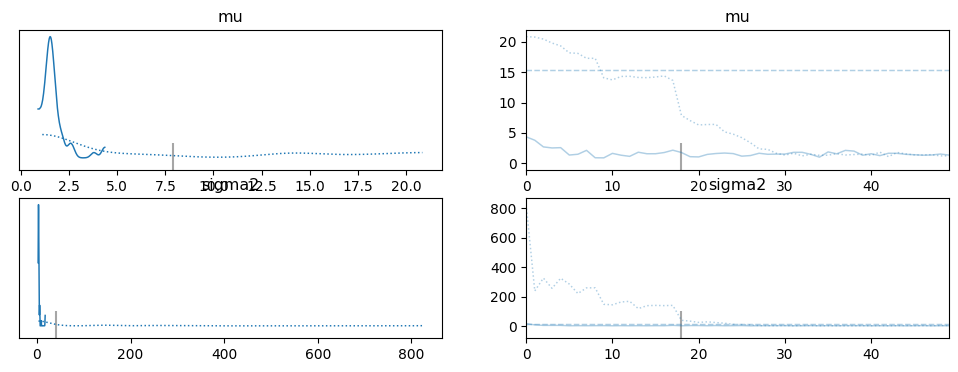

In [89]:
#2
# Replicar traceplot para mu y sigma2
az.plot_trace(jags_fit_pred, var_names=["mu", "sigma2"])
plt.show()

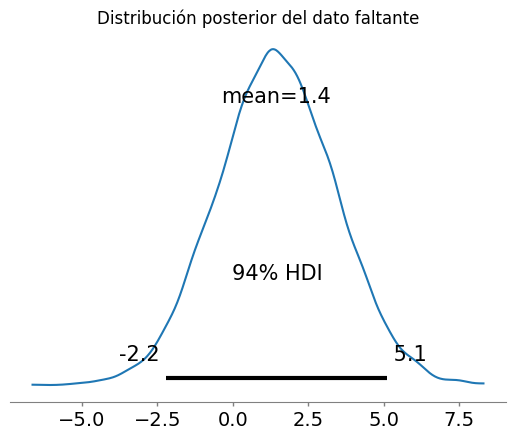

In [90]:
#3
# Graficar la distribución del valor imputado
az.plot_posterior(jags_fit_imputacion, var_names=["x_unobserved"])
plt.title("Distribución posterior del dato faltante")
plt.show()

In [91]:
#4

# Generar el resumen estadístico
resumen = az.summary(jags_fit_pred)
print(resumen)

          mean      sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
mu       8.243   6.957   0.902   17.298      3.603    0.356       5.0   
nu       0.154   0.122   0.001    0.332      0.062    0.008       4.0   
sigma2  37.933  92.670   2.533  221.690     35.851   48.254       4.0   

        ess_tail  r_hat  
mu          14.0   1.79  
nu          12.0   2.16  
sigma2      12.0   2.24  


Muestreador de Gibbs

In [92]:
#1
import numpy as np
import pymc as pm

# Ejemplo de definición de datos (ajustar según tus datos reales)
# x: resultados (0 o 1)
# coin: identificador de la moneda para cada observación
x = np.array([1, 0, 1, 1, 0, 1, 0, 0])
coin = np.array([1, 1, 1, 2, 2, 3, 3, 3])

# Crear coin_idx empezando en 0
coin_idx = coin - 1
n_coins = len(np.unique(coin_idx))

with pm.Model() as modelo_jerarquico:
    mu = pm.Beta('mu', alpha=2, beta=2)
    kappa = pm.Gamma('kappa', alpha=1, beta=0.1)

    a = pm.Deterministic('a', mu * kappa)
    b = pm.Deterministic('b', (1 - mu) * kappa)

    theta = pm.Beta('theta', alpha=a, beta=b, shape=n_coins)

    x_obs = pm.Bernoulli('x', p=theta[coin_idx], observed=x)
    trace_jer = pm.sample(2000, tune=1000)

Output()

In [93]:
#2

# Definición de datos
x = np.array([0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1])
coin = np.array([1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 5, 5, 5, 5, 5])
coin_idx = coin - 1
n_coins = 5

# Función para valores iniciales
def get_inits():
    return {
        "mu": np.random.uniform(0.1, 0.9),
        "kappa": np.random.uniform(5, 20)
    }

# Definición del modelo jerárquico
with pm.Model() as modelo_jerarquico:
    # Hyperpriors
    mu = pm.Beta('mu', alpha=2, beta=2)
    kappa = pm.Gamma('kappa', alpha=1, beta=0.1)

    # Parámetros de la distribución Beta
    a = pm.Deterministic('a', mu * kappa)
    b = pm.Deterministic('b', (1 - mu) * kappa)

    # Prior para cada moneda (vector de parámetros theta)
    theta = pm.Beta('theta', alpha=a, beta=b, shape=n_coins)

    # Verosimilitud
    x_obs = pm.Bernoulli('x', p=theta[coin_idx], observed=x)

    # Muestreo (equivalente a jags_fit)
    jags_fit = pm.sample(
        draws=9000,
        tune=1000,
        chains=3,
        initvals=[get_inits() for _ in range(3)],
        random_seed=122
    )

Output()

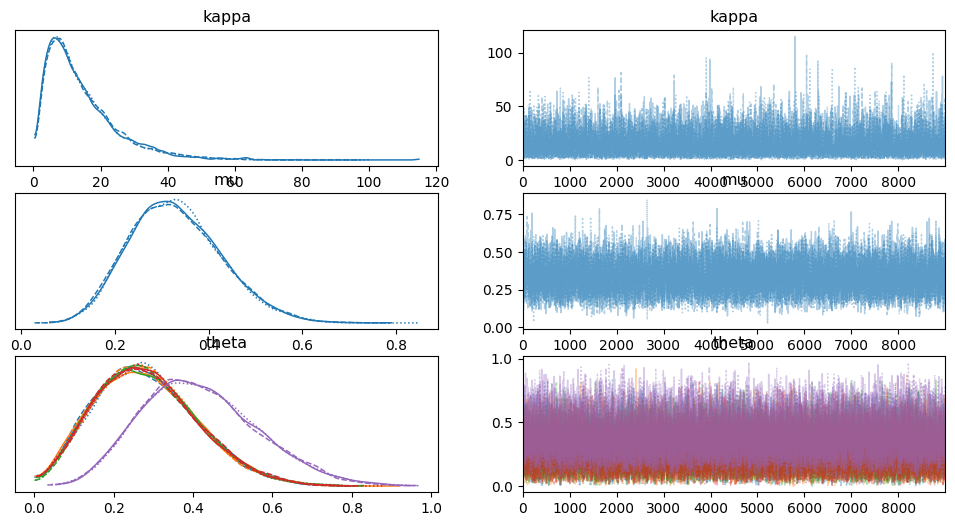

In [94]:
#3

az.plot_trace(jags_fit, var_names=["kappa", "mu", "theta"])
plt.show()

In [95]:
#4

# Resumen de estadísticas posteriores y diagnósticos de convergencia
resumen = az.summary(jags_fit, var_names=["mu", "kappa", "theta"])
print(resumen)

            mean      sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
mu         0.330   0.098   0.154    0.515      0.001    0.001   11247.0   
kappa     14.353  10.797   0.887   34.028      0.115    0.169    9357.0   
theta[0]   0.283   0.129   0.043    0.510      0.001    0.001   13528.0   
theta[1]   0.283   0.129   0.048    0.516      0.001    0.001   16290.0   
theta[2]   0.285   0.129   0.054    0.519      0.001    0.001   15058.0   
theta[3]   0.284   0.129   0.046    0.516      0.001    0.001   16692.0   
theta[4]   0.416   0.146   0.157    0.693      0.001    0.001   15506.0   

          ess_tail  r_hat  
mu         14943.0    1.0  
kappa      11543.0    1.0  
theta[0]   13181.0    1.0  
theta[1]   14321.0    1.0  
theta[2]   14438.0    1.0  
theta[3]   14937.0    1.0  
theta[4]   17442.0    1.0  


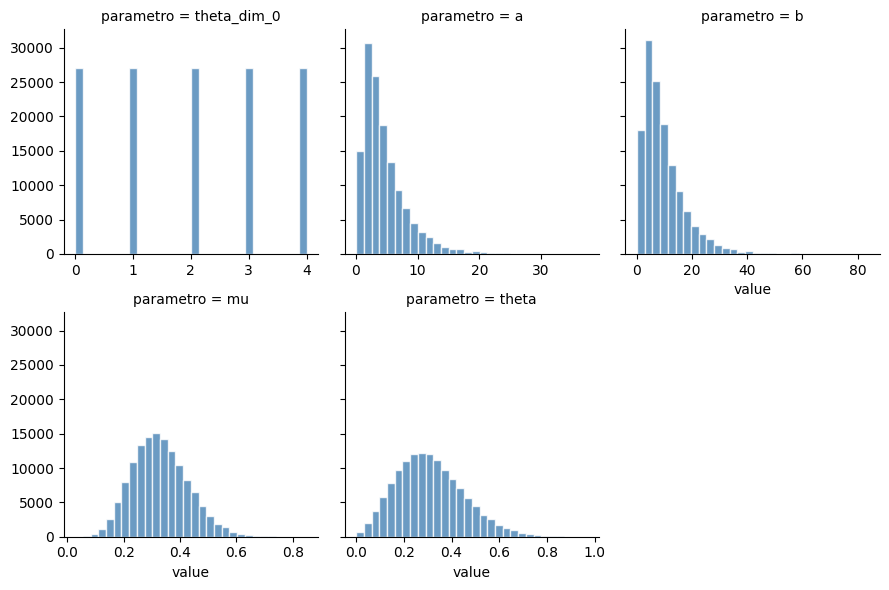

In [96]:
#5
# 1. El objeto jags_fit ya tiene el método .to_dataframe()
# Usamos .posterior para obtener solo las muestras de los parámetros
df = jags_fit.posterior.to_dataframe().reset_index()

# 2. Filtrar para quitar kappa (como hacías en R)
# Nota: PyMC suele nombrar las columnas como 'mu', 'kappa', 'theta[0]', etc.
columnas_sin_kappa = [c for c in df.columns if 'kappa' not in c and c not in ['chain', 'draw']]
df_filtered = df[columnas_sin_kappa + ['chain', 'draw']]

# 3. Transformar a formato largo (melt) para las facetas
df_tidy = df_filtered.melt(id_vars=['chain', 'draw'], var_name='parametro', value_name='value')

# 4. Graficar histogramas con facetas (Seaborn es el ggplot de Python)
import seaborn as sns
import matplotlib.pyplot as plt

g = sns.FacetGrid(df_tidy, col="parametro", col_wrap=3, sharex=False)
g.map(plt.hist, "value", alpha=0.8, bins=30, color="steelblue", edgecolor="white")
# plt.show()

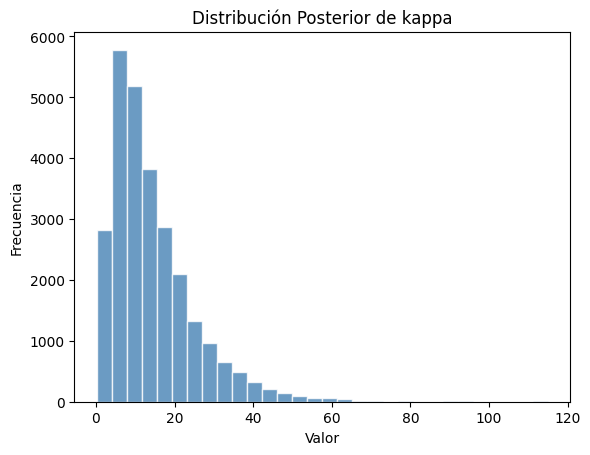

In [97]:
#6
kappa_posterior = jags_fit.posterior['kappa'].values.flatten()

# Graficar el histograma
plt.hist(kappa_posterior, bins=30, alpha=0.8, color="steelblue", edgecolor="white")
plt.title("Distribución Posterior de kappa")
plt.xlabel("Valor")
plt.ylabel("Frecuencia")
plt.show()